In [1]:
import numpy as np
print("Working!")

Working!


In [5]:
import sys
!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 7.1 MB/s eta 0:00:007.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 1.5 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn]0m 4/5 [scikit-learn]

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /Users/vemula/myenv/bin/python -m pip install --upgrade pip


In [1]:
import sklearn
print("Sklearn working ✅")

Sklearn working ✅


Train Shape: (60000, 28, 28)
Test Shape: (10000, 28, 28)


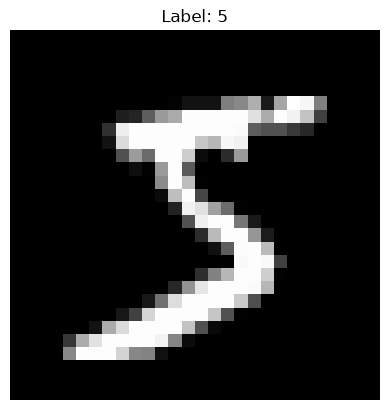

/Users/vemula/myenv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 472us/step - accuracy: 0.8721 - loss: 0.4854 - val_accuracy: 0.9267 - val_loss: 0.2722
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 414us/step - accuracy: 0.9122 - loss: 0.3140 - val_accuracy: 0.9332 - val_loss: 0.2463
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 419us/step - accuracy: 0.9181 - loss: 0.2917 - val_accuracy: 0.9360 - val_loss: 0.2361
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 409us/step - accuracy: 0.9203 - loss: 0.2808 - val_accuracy: 0.9372 - val_loss: 0.2304
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 420us/step - accuracy: 0.9229 - loss: 0.2737 - val_accuracy: 0.9392 - val_loss: 0.2281
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 448us/step - accuracy: 0.9253 - loss: 0.2684 - val_accuracy: 0.9385 - val_loss: 0.2260
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 435us/step - accuracy: 0.9260 - loss: 0.2643 - val_accuracy: 0.9393 - val_loss: 0.2248
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 434us/step - accuracy: 0.9269 -

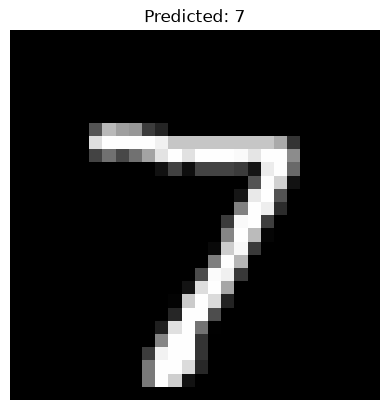

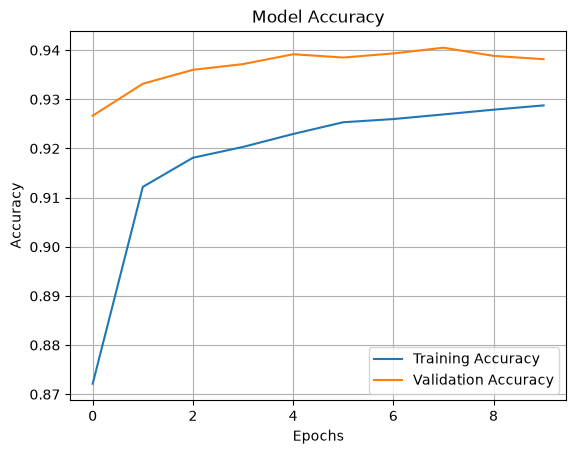

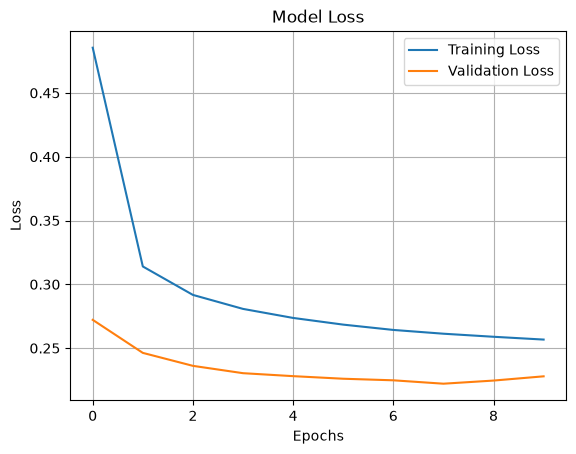

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 236us/step


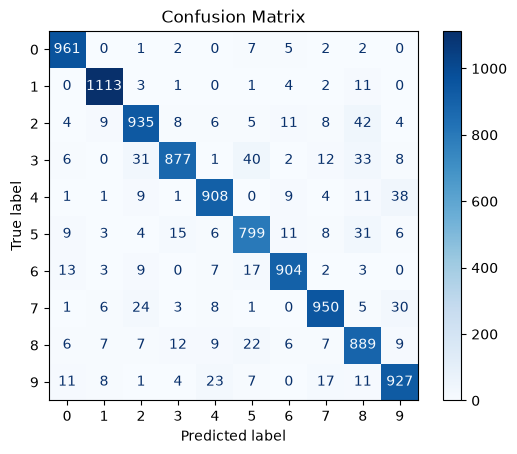

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()


model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(10, activation='softmax')
])

model.summary()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.1
)



test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")


sample = X_test[0]
pred = model.predict(sample.reshape(1, 28, 28))

predicted_digit = np.argmax(pred)

print("Actual:", y_test[0])
print("Predicted:", predicted_digit)

plt.imshow(sample, cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.axis('off')
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.grid()
plt.show()

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [3]:
import numpy as np
def step(z):
    return 1 if z >= 0 else 0
def train_perceptron(X, y, lr=0.1, epochs=10):
    weights = np.zeros(X.shape[1])
    bias = 0

    for epoch in range(epochs):
        for i in range(len(X)):
            z = np.dot(X[i], weights) + bias
            y_pred = step(z)

            error = y[i] - y_pred

            weights += lr * error * X[i]
            bias += lr * error

    return weights, bias
def test_perceptron(X, weights, bias):
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        print(f"Input: {X[i]} → Output: {step(z)}")

In [4]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

w, b = train_perceptron(X, y)

print("\nAND Gate")
test_perceptron(X, w, b)


AND Gate
Input: [0 0] → Output: 0
Input: [0 1] → Output: 0
Input: [1 0] → Output: 0
Input: [1 1] → Output: 1


In [5]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([1,1,1,0])

w, b = train_perceptron(X, y)

print("\nNAND Gate")
test_perceptron(X, w, b)


NAND Gate
Input: [0 0] → Output: 1
Input: [0 1] → Output: 1
Input: [1 0] → Output: 1
Input: [1 1] → Output: 0


In [6]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([1,0,0,0])

w, b = train_perceptron(X, y)

print("\nNOR Gate")
test_perceptron(X, w, b)


NOR Gate
Input: [0 0] → Output: 1
Input: [0 1] → Output: 0
Input: [1 0] → Output: 0
Input: [1 1] → Output: 0


In [7]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,1])

w, b = train_perceptron(X, y)

print("\nOR Gate")
test_perceptron(X, w, b)


OR Gate
Input: [0 0] → Output: 0
Input: [0 1] → Output: 1
Input: [1 0] → Output: 1
Input: [1 1] → Output: 1
